## Assignment-1

The assignment is divided into three main topics:

- **Hashing and Sketching:** Implement and analyze different hashing strategies, including universal hashing and MD5-based functions. The aim is to compare their performance in terms of collision handling (chain lengths) and apply them to implement the Flajolet-Martin algorithm for estimating the number of unique items in a dataset.

- **Data Streaming Algorithms:** Using a large transactional dataset, implement and evaluate two key streaming algorithms. The first is the Bloom Filter, where the objective is to analyze its false positive rate under various parameters. The second is the Misra-Gries algorithm, where the aim is to identify frequent items from the data stream and compare the algorithm's accuracy against the exact counts.

- **Dimensionality Reduction:** Use the KDD Cup dataset to explore the effects of Johnson-Lindenstrauss (JL) random projections. The objective is to apply these projections to the data and then measure how this dimensionality reduction impacts the cost and loss of two standard machine learning tasks: k-means clustering and linear regression.



### Authors
| Name | Roll Number |
|---|---|
| Anushk Kumar | 2023115 |
| Arhan Jain | 2023118 |


Importing all the required Libraries
```bash
numpy
sklearn
matplotlib
hashlib
tqdm

```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import random
import math
from tqdm import tqdm
from sklearn.datasets import fetch_kddcup99
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import euclidean_distances
from scipy.sparse import csc_matrix

## Question 1
Here are the objectives and formulas for Question 1, based on the provided assignment details.

### Question 1(a): Hash Table Class

* **Objective:** To create a Python class for a hash table that uses chaining to handle collisions. The hash table should use a universal hash function.
* **Formula (Universal Hash Function):**
    $$h_{a}(x) = ((ax) \pmod p) \pmod m$$
* **Constants:**
    * Prime number: $p = 524287$
    * Table size: $m$ (user-specified)
    * Multiplier: $a$ (chosen randomly)


### Question 1(b): MD5 Hash Function

* **Objective:** To implement a hash function for strings using the md5 library. The hash value should be derived from the last 4 digits of the md5 hexdigest.
* **Formula (Hash Value Range):**
    * The hash function maps a string to an integer index in the range $[0, 16^4 - 1]$, which is $[0, 65535]$.



### Question 1(c): Hash Function Comparison

* **Objective:** To experimentally compare the **maximum chain length** and **minimum chain length** for two different hash functions by hashing all numbers from $1$ to $m$.
* **Hash Function 1 (Universal):**
    * $h_{a}(x) = ((ax) \pmod p) \pmod m$ (from part 1a)
* **Hash Function 2 (Random):**
    * $h[x] = \text{int}(m \cdot \text{random.random()})$
* **Constants:**
    * Table size: $m = 50000$



### Question 1(d): Flajolet-Martin Algorithm

* **Objective:** To estimate the number of unique words in the file using the Flajolet-Martin algorithm.
* **Process:**
    1.  Use the last 4 digits from part 1(b) as the `id` for each word.
    2.  Hash each `id` using the universal hash function $h_a(x)$ from part 1(a).
    3.  Compute the number of trailing zeros for each hash value.
    4.  Maintain $z$, the maximum number of trailing zeros observed across all `id`s.
* **Formula (Uniqueness Estimate):**
    $$\text{Estimated Unique Count} = 2^{z + 1/2}$$

In [2]:
class Hash_Table:
    def __init__(self, m = 1, hashing = "default", p = 524287):
        if (hashing == "default"):
            self.A = [[] for i in range(m)]
            self.p = p
            self.m = m
            self.a = random.randrange(1, p)
        else:
            self.hash_dict = {}
            self.m = m
            for i in range(m):
                self.hash_dict[i] = []
        
    def universal_hash_function(self, X):
        h_x = ((self.a * X) % self.p) % self.m
        self.insert_uni(h_x, X)
        return h_x
    
    def insert_uni(self, hash, X):
        self.A[hash].append(X)
        
    def hash_md5_string(string):
        has = hashlib.sha256(string.encode('utf-8')).hexdigest()
        dec_from_hex = {'0':0, '1':1, '2':2, '3':3, '4':4, '5':5, '6':6, '7':7, '8':8, '9':9, 'a':10, 'b':11, 'c':12, 'd':13, 'e':14, 'f':15}
        to_dec = dec_from_hex[has[-4]]*(16**3) + dec_from_hex[has[-3]]*(16**2) + dec_from_hex[has[-2]]*16 + dec_from_hex[has[-1]]
        return to_dec

    def random_hash_function(self, X):
        h_x = int(self.m * random.random())
        self.insert_rand(h_x, X)
        return h_x
    
    def insert_rand(self, hash, X):
        if hash in self.hash_dict.keys():
            self.hash_dict[hash].append(X)
        else:
            self.hash_dict[hash] = [X]

In [3]:
# Q1 a)
hash_table = Hash_Table(m=10)
hash_table.universal_hash_function(123456)
hash_table.universal_hash_function(654321)
print("Universal Hash Table:")
print(hash_table.A)

Universal Hash Table:
[[], [], [654321], [], [], [], [123456], [], [], []]


In [4]:
# Q1 b)
df = pd.DataFrame(columns = ['String', 'HashVal'])
words = []
with open('words.txt', 'r') as f:
    words = f.readlines()

word_hash = []
has_vals = []

for w in words:
    temp = w
    if (w[-1] == '\n'):
        temp = w[:-1]
    word_hash.extend([temp])
    has_vals.extend([Hash_Table.hash_md5_string(temp)])

df['String'] = word_hash
df['HashVal'] = has_vals
print(df)
df.to_csv('hash_values.csv', index = False)
print("Results stored in hash values.csv")

          String  HashVal
0             &c    28641
1             'd    57875
2            'em     9693
3            'll    21266
4             'm    63676
...          ...      ...
354981   zymurgy    19698
354982    zythem    30716
354983    zythum    56039
354984   zyzzyva    57306
354985  zyzzyvas    62567

[354986 rows x 2 columns]
Results stored in hash values.csv


Universal Hashing :
        Max : 2           Min : 0
        Max : 2           Min : 0
        Max : 2           Min : 0
        Max : 2           Min : 0
        Max : 2           Min : 0
Random Hashing :
        Max : 9           Min : 0
        Max : 8           Min : 0
        Max : 9           Min : 0
        Max : 8           Min : 0
        Max : 8           Min : 0


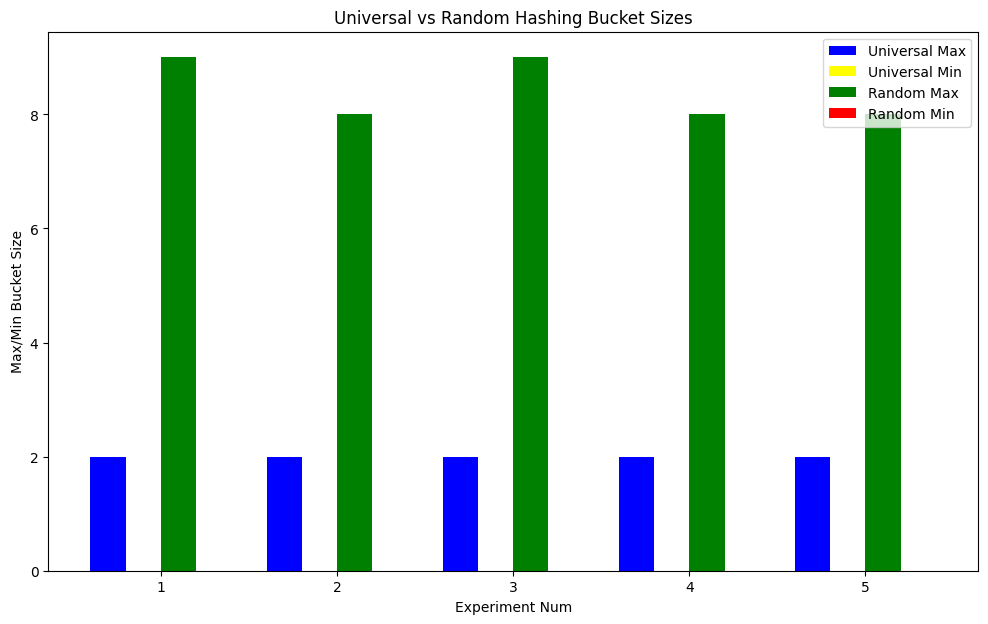

Random Hashing has more difference between the maximum and minimum chain


In [5]:
# Q1 c)
m = 500000
uni = Hash_Table(m)
ran = Hash_Table(m, hashing = "random")

results = {"Universal Hashing": [], "Random Hashing": []}

for i in range(5):
    for j in range(1, m+1):
        uni.universal_hash_function(j)
        ran.random_hash_function(j)
    results["Universal Hashing"].append({'Max' : 0, 'Min' : m})
    for j in uni.A:
        if (len(j) > results["Universal Hashing"][-1]['Max']):
            results["Universal Hashing"][-1]['Max'] = len(j)
        if (len(j) < results["Universal Hashing"][-1]['Min']):
            results["Universal Hashing"][-1]['Min'] = len(j)
            
    results["Random Hashing"].append({'Max' : 0, 'Min' : m})
    for key in ran.hash_dict.keys():
        l = len(ran.hash_dict[key])
        if (l > results["Random Hashing"][-1]['Max']):
            results["Random Hashing"][-1]['Max'] = l
        if (l < results["Random Hashing"][-1]['Min']):
            results["Random Hashing"][-1]['Min'] = l
    
    uni = Hash_Table(m)
    ran = Hash_Table(m, hashing = "random")
    
for has in results.keys():
    print(f"{has} :")
    for i in range(5):
        print(f"        Max : {results[has][i]['Max']} {' '*(10-len(str(results[has][i]['Max'])))} Min : {results[has][i]['Min']}")
        
uma = [result['Max'] for result in results["Universal Hashing"]]
umi = [result['Min'] for result in results["Universal Hashing"]]
rma = [result['Max'] for result in results["Random Hashing"]]
rmi = [result['Min'] for result in results["Random Hashing"]]
plt.figure(figsize=(12, 7))
x = np.arange(1, 6)
plt.bar(x - 1.5 * 0.2, uma, width=0.2, label='Universal Max', color='blue')
plt.bar(x - 0.5 * 0.2, umi, width=0.2, label='Universal Min', color='yellow')
plt.bar(x + 0.5 * 0.2, rma, width=0.2, label='Random Max', color='green')
plt.bar(x + 1.5 * 0.2, rmi, width=0.2, label='Random Min', color='red')

plt.xlabel('Experiment Num')
plt.ylabel('Max/Min Bucket Size')
plt.title('Universal vs Random Hashing Bucket Sizes')
plt.xticks(x)
plt.legend()
plt.show()

if (max(uma) - min(umi) < max(rma) - min(rmi)):
    print("Random Hashing has more difference between the maximum and minimum chain")
else:
    print("Universal Hashing has more difference between the maximum and minimum chain")

In [6]:
def dec_to_bin(n):
    binar = ''
    while (n > 0):
        binar += str(str(n%2))
        n = n//2
    return binar

def Flajolet_Martin():
    words = []
    with open('words.txt', 'r') as f:
        words = f.readlines()

    has_vals = []

    for w in words:
        temp = w
        if (w[-1] == '\n'):
            temp = w[:-1]
        has_vals.extend([Hash_Table.hash_md5_string(temp)])
    
    for m in [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]:
        max_z = 0
        hash_table = Hash_Table(m)
        for i in has_vals:
            h_x = hash_table.universal_hash_function(i)
            bi = dec_to_bin(h_x)
            z = 0
            for k in bi:
                if (k == '0'):
                    z += 1
                else:
                    break
            max_z = max(max_z, z)
            
        est = 2**(max_z + 0.5)
        print(f"m : {m} {' '*(10-len(str(m)))} Max z : {max_z} {' '*(10-len(str(max_z)))} Distinct Words : {math.floor(est)}")
        
Flajolet_Martin()

m : 8           Max z : 2           Distinct Words : 5
m : 16          Max z : 3           Distinct Words : 11
m : 32          Max z : 4           Distinct Words : 22
m : 64          Max z : 5           Distinct Words : 45
m : 128         Max z : 6           Distinct Words : 90
m : 256         Max z : 7           Distinct Words : 181
m : 512         Max z : 8           Distinct Words : 362
m : 1024        Max z : 9           Distinct Words : 724
m : 2048        Max z : 10          Distinct Words : 1448
m : 4096        Max z : 11          Distinct Words : 2896
m : 8192        Max z : 12          Distinct Words : 5792
m : 16384       Max z : 12          Distinct Words : 5792
m : 32768       Max z : 14          Distinct Words : 23170
m : 65536       Max z : 13          Distinct Words : 11585


## Question 2
### Q2(a) Bloom Filter implementation


1. **False Positive Rate (FPR)**:
   - The probability that a non-present item is incorrectly identified as present.
   - Formula:
     $$ FPR \approx \left(1 - e^{-\frac{k \cdot n}{m}}\right)^k $$
     where:
     - \( m \): Size of the bit array.
     - \( k \): Number of hash functions.
     - \( n \): Number of items inserted (number of unique `StockCode` values).

2. **Optimal Number of Hash Functions**:
   - Minimizes FPR for given \( m \) and \( n \).
   - Formula:
     $$ k_{opt} = \frac{m}{n} \cdot \ln(2) \approx 0.693 \cdot \frac{m}{n} $$
     Example: For \( m = 10000 \), \( n \approx 4000 \), 
     $$ k_{opt} \approx 0.693 \cdot \frac{10000}{4000} = 0.693 \cdot 2.5 \approx 1.7325 $$
     Thus, \( k ~ 4 \) or \( k ~ 5 \) is optimal, though \( k = 7 \) is reasonable for practical purposes.

3. **Sensitivity**:
   - The probability that a present item is correctly identified (true positive rate).
   - Formula:
     $$ \text{Sensitivity} = 1 $$
     Since Bloom Filters have no false negatives, all present items are correctly identified.

4. **Experimental FPR Calculation**:
   - Empirical FPR is calculated as:
     $$ \text{FPR} = \frac{\text{Number of false positives}}{\text{Number of non-present items tested}} $$
     where false positives are non-present items incorrectly identified as present.

In [7]:
class BloomFilter:
    def __init__(self, size, hashfuncCnt):
        self.size = int(size)          # M 
        self.hashfuncCnt = hashfuncCnt # K 
        self.bitArray = [0] * self.size

    def addElement(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            self.bitArray[hash] = 1

    def existCheck(self, element):
        kHash = self.hashFunction(element, seed=42)
        for hash in kHash:
            if self.bitArray[hash] == 0:
                return False
        return True

    def hashFunction(self, element, seed):
        kHash = []
        for i in range(self.hashfuncCnt):
            hash = (hashlib.md5((str(element) + str(seed) + str(i)).encode()).hexdigest())
            kHash.append(int(hash, 16) % self.size)
        return kHash

In [8]:
retailDf = pd.read_csv('online-retail.csv')
uniqueStkCodes = retailDf['StockCode'].unique().tolist()
present_set = set(uniqueStkCodes)
n = len(uniqueStkCodes)
print("Uniq Seqs : ",n)

Uniq Seqs :  4070


Using default m = 40700.0, default k = 6 (calculated optimal for m,n)
Generated test sets of present and not-present items.

--- Starting Bloom Filter Experiments (Part a) ---

Sensitivity (True Positive Rate) Check:
Items tested: 1000
Items found: 1000
Sensitivity: 1.0
Validation successful: Sensitivity is 1, as expected.

Running Experiment: FPR vs. m


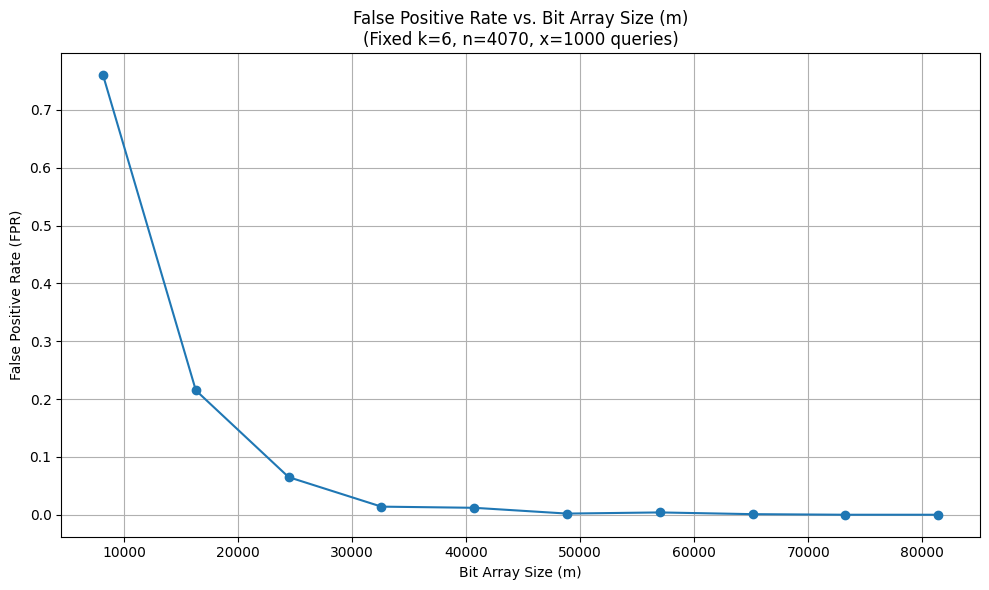


Experiment: FPR vs. k


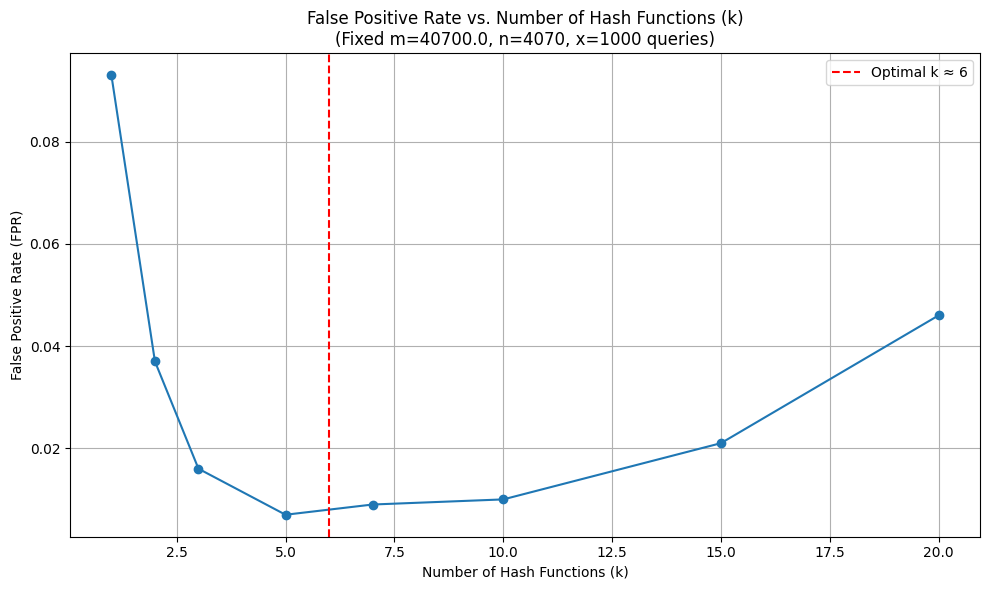


Experiment: FPR vs. x


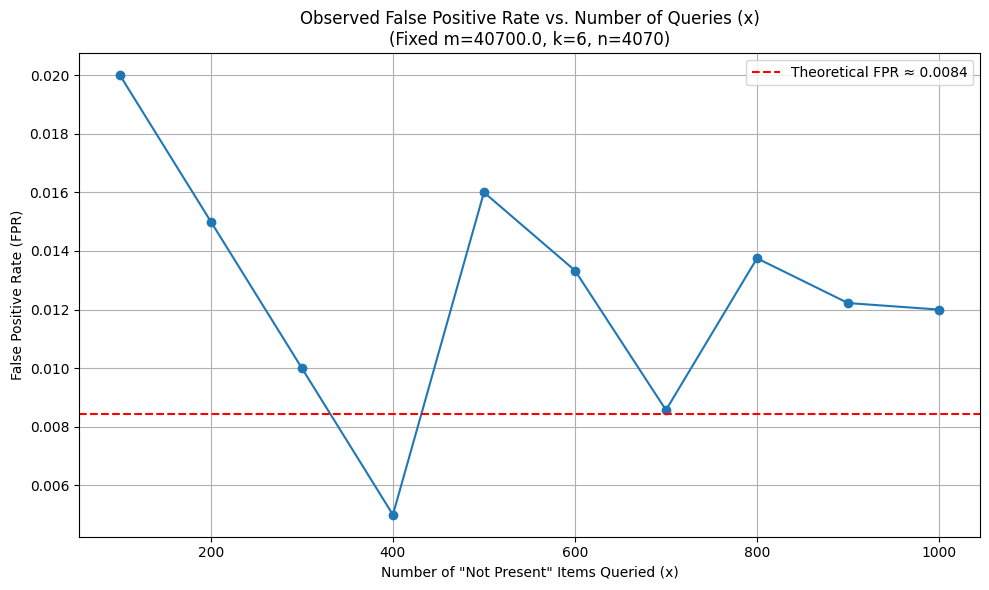

In [ ]:
XCNT_VAL = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
RANDOM_PRESENT_VALUES_MAP = {}
RANDOM_NOT_PRESENT_VALUES_MAP = {}

DEFAULT_M = 40700.
optimal_k = int((DEFAULT_M / n) * np.log(2))

DEFAULT_K = max(1, optimal_k) 
print(f"Using default m = {DEFAULT_M}, default k = {DEFAULT_K} (calculated optimal for m,n)")

for i in XCNT_VAL:
    RANDOM_PRESENT_VALUES_MAP[i] = random.sample(uniqueStkCodes, k=i)

not_present_items = []
i = 0
while len(not_present_items) < max(XCNT_VAL):
    item = f"KABOOM1234-{i}" 
    if item not in present_set:
        not_present_items.append(item)
    i += 1

for j in XCNT_VAL:
    RANDOM_NOT_PRESENT_VALUES_MAP[j] = random.sample(not_present_items, k=j)

print("Generated test sets of present and not-present items.")

# Q2 a) True Positive Rate 

print("\n--- Starting Bloom Filter Experiments (Part a) ---")
bf_sensitivity = BloomFilter(DEFAULT_M, DEFAULT_K)

for item in uniqueStkCodes:
    bf_sensitivity.addElement(item)

present_test_list = RANDOM_PRESENT_VALUES_MAP[1000]
true_positives = 0
for item in present_test_list:
    if bf_sensitivity.existCheck(item):
        true_positives += 1

sensitivity = true_positives / len(present_test_list)

print(f"\nSensitivity (True Positive Rate) Check:")
print(f"Items tested: {len(present_test_list)}")
print(f"Items found: {true_positives}")
print(f"Sensitivity: {sensitivity}")
if sensitivity == 1.0:
    print("Validation successful: Sensitivity is 1, as expected.")
else:
    print("Validation FAILED: Sensitivity is not 1")


# Q2 a) Graphs
print("\nRunning Experiment: FPR vs. m")
m_values = [n * i for i in range(2, 21, 2)]
fpr_vs_m = []
fixed_k = DEFAULT_K
fixed_x = 1000
test_items_not_present = RANDOM_NOT_PRESENT_VALUES_MAP[fixed_x]

for m in m_values:
    bf = BloomFilter(size=m, hashfuncCnt=fixed_k)
    for item in uniqueStkCodes:
        bf.addElement(item)
    
    fp_count = 0
    for item in test_items_not_present:
        if bf.existCheck(item):
            fp_count += 1
    
    fpr = fp_count / fixed_x
    fpr_vs_m.append(fpr)

plt.figure(figsize=(10, 6))
plt.plot(m_values, fpr_vs_m, marker='o', linestyle='-')
plt.title(f'False Positive Rate vs. Bit Array Size (m)\n(Fixed k={fixed_k}, n={n}, x={fixed_x} queries)')
plt.xlabel('Bit Array Size (m)')
plt.ylabel('False Positive Rate (FPR)')
plt.grid(True)
plt.tight_layout()
plt.show()


print("\nExperiment: FPR vs. k")
k_values = [1, 2, 3, 5, 7, 10, 15, 20]
fpr_vs_k = []
fixed_m = DEFAULT_M
fixed_x = 1000
test_items_not_present = RANDOM_NOT_PRESENT_VALUES_MAP[fixed_x]

for k in k_values:
    bf = BloomFilter(size=fixed_m, hashfuncCnt=k)
    for item in uniqueStkCodes:
        bf.addElement(item)
        
    fp_count = 0
    for item in test_items_not_present:
        if bf.existCheck(item):
            fp_count += 1
            
    fpr = fp_count / fixed_x
    fpr_vs_k.append(fpr)

plt.figure(figsize=(10, 6))
plt.plot(k_values, fpr_vs_k, marker='o', linestyle='-')
plt.title(f'False Positive Rate vs. Number of Hash Functions (k)\n(Fixed m={fixed_m}, n={n}, x={fixed_x} queries)')
plt.xlabel('Number of Hash Functions (k)')
plt.ylabel('False Positive Rate (FPR)')
plt.axvline(x=DEFAULT_K, color='r', linestyle='--', label=f'Optimal k ≈ {DEFAULT_K}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nExperiment: FPR vs. x")
x_values = XCNT_VAL
fpr_vs_x = []
fixed_m = DEFAULT_M
fixed_k = DEFAULT_K


bf = BloomFilter(size=fixed_m, hashfuncCnt=fixed_k)
for item in uniqueStkCodes:
    bf.addElement(item)

for x in x_values:
    test_items_not_present = RANDOM_NOT_PRESENT_VALUES_MAP[x]
    fp_count = 0
    for item in test_items_not_present:
        if bf.existCheck(item):
            fp_count += 1
            
    fpr = fp_count / x
    fpr_vs_x.append(fpr)


plt.figure(figsize=(10, 6))
plt.plot(x_values, fpr_vs_x, marker='o', linestyle='-')

theo_fpr = (1 - (1 - 1/fixed_m)**(fixed_k * n))**fixed_k


plt.axhline(y=theo_fpr, color='r', linestyle='--', label=f'Theoretical FPR ≈ {theo_fpr:.4f}')
plt.title(f'Observed False Positive Rate vs. Number of Queries (x)\n(Fixed m={fixed_m}, k={fixed_k}, n={n})')
plt.xlabel('Number of "Not Present" Items Queried (x)')
plt.ylabel('False Positive Rate (FPR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Q2(b) Misra-Gries Algorithm

**Source:** `https://www.cs.dartmouth.edu/~ac/Teach/data-streams-lecnotes.pdf`

### Misra-Gries Algorithm Formulas

### 1. Stream and Frequency
- Let $S = \{ s_1, s_2, \dots, s_n \}$ be the stream of $n$ items (e.g., `StockCode` values).
- The **true frequency** of item $i$ is $f_i$:
  $$
  f_i = |\{ j : s_j = i \}|
  $$
  where $f_i$ is the number of times item $i$ appears in $S$.
- The **estimated frequency** from Misra-Gries is $\hat{f_i}$.


### 2. Misra-Gries Guarantee
- The algorithm guarantees to identify all items with frequency $f_i > \frac{n}{k}$.
- For each item $i$ in the output dictionary, the estimate $\hat{f_i}$ is bounded:
  $$
  f_i - \frac{n}{k} \leq \hat{f_i} \leq f_i
  $$
  where $\frac{n}{k}$ is the theoretical error bound on frequency estimates.




### 4. Maximum Frequency Error
- The **Maximum Error** in frequency estimates for items in the Misra-Gries output:
  $$
  \text{Max Error} = \max_{i \in \text{Misra-Gries items}} | f_i - \hat{f_i} |
  $$
- **Normalized max error** (for plotting):
  $$
  \frac{\text{Max Error}}{n}
  $$


### 5. Theoretical Error Bound
- The **theoretical upper bound** on frequency error:
  $$
  \text{Theoretical Bound} = \frac{n}{k}
  $$
- **Normalized theoretical bound**:
  $$
  \frac{\text{Theoretical Bound}}{n} = \frac{1}{k}
  $$



In [10]:
class DataStream:
    def __init__(self, thresh: int):
        if thresh <= 0:
            raise ValueError("Threshold must be positive")
        self.thresh = thresh
        self.freq_map = {}

    def addElement(self, element):
        if element in self.freq_map.keys():
            self.freq_map[element] += 1
        else:
            self.freq_map[element] = 1
        if len(self.freq_map) >= self.thresh:
            keys_to_remove = []
            for key in self.freq_map.keys():
                self.freq_map[key] -= 1
                if self.freq_map[key] == 0:
                    keys_to_remove.append(key)
            for key in keys_to_remove:
                del self.freq_map[key]

    def queryEle(self, element):
        if element in self.freq_map.keys():
            return self.freq_map.get(element,0)
    
    def freqElereturn(self):
        return self.freq_map

In [11]:
dataframe = pd.read_csv('online-retail.csv')
stockCodes = dataframe['StockCode']
direct_freq_map = {}
for code in stockCodes:
    if code in direct_freq_map:
        direct_freq_map[code] += 1
    else:
        direct_freq_map[code] = 1

print("Direct frequency count of elements:")
print(len(direct_freq_map))
n = len(stockCodes)
print(f"Total items in stream: {n}")
print(f"Unique StockCodes: {len(direct_freq_map)}")

Direct frequency count of elements:
4070
Total items in stream: 541909
Unique StockCodes: 4070


   k  Accuracy (Top-50 Found)  Max. Observed Error  Theoretical Bound (N/k)
  10                     0.02                 2313                 54190.90
  25                     0.06                 2313                 21676.36
  50                     0.06                 2313                 10838.18
 100                     0.10                 2313                  5419.09
 300                     0.46                 1799                  1806.36
 700                     1.00                  712                   774.16
 900                     1.00                  521                   602.12
1000                     1.00                  452                   541.91


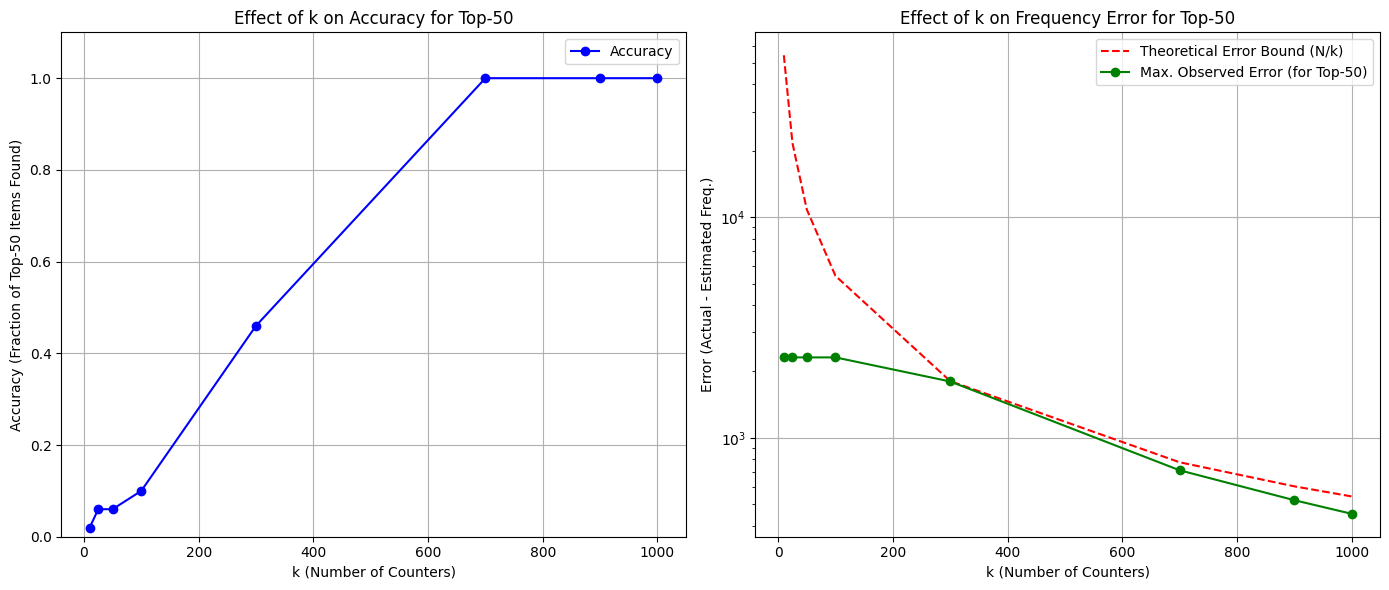

In [12]:
k_values = [10,25,50, 100, 300, 700,900, 1000]

actual_top_50 = sorted(direct_freq_map.items(), key=lambda x: x[1], reverse=True)[:50]
actual_top_50_items = {item for item, _ in actual_top_50}
n = len(stockCodes)

results = []

for k in k_values:
    misra_gries = DataStream(thresh=k)
    for code in stockCodes:
        misra_gries.addElement(code)
    
    estimated_freq_map = misra_gries.freqElereturn()
    
    items_found = actual_top_50_items.intersection(estimated_freq_map.keys())
    accuracy = len(items_found) / 50
    
    theoretical_error_bound = n / k
    
    observed_errors = []
    for item, actual_freq in actual_top_50:
        estimated_freq = estimated_freq_map.get(item, 0)
        error = actual_freq - estimated_freq
        observed_errors.append(error)
    
    max_observed_error = np.max(observed_errors)
    
    results.append({
        'k': k,
        'Accuracy (Top-50 Found)': accuracy,
        'Max. Observed Error': max_observed_error,
        'Theoretical Bound (N/k)': theoretical_error_bound
    })


results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="%.2f"))


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(results_df['k'], results_df['Accuracy (Top-50 Found)'], 'bo-', label='Accuracy')
plt.title('Effect of k on Accuracy for Top-50')
plt.xlabel('k (Number of Counters)')
plt.ylabel('Accuracy (Fraction of Top-50 Items Found)')
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(results_df['k'], results_df['Theoretical Bound (N/k)'], 'r--', label='Theoretical Error Bound (N/k)')
plt.plot(results_df['k'], results_df['Max. Observed Error'], 'go-', label='Max. Observed Error (for Top-50)')
plt.title('Effect of k on Frequency Error for Top-50')
plt.xlabel('k (Number of Counters)')
plt.ylabel('Error (Actual - Estimated Freq.)')
plt.yscale('log')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


###  Question 3(a): k-means Clustering

The objective is to compute and compare the k-means clustering cost on the original dataset $D$ using two different sets of centroids:
1.  **Centroids B:** Computed from the original data $D$.
2.  **Centroids A:** Computed from the randomly projected data $E = DM$ (where $M \in \mathbb{R}^{d \times x}$), and then transformed back into the original $d$-dimensional space.

**Formulas:**

* **Data Matrix:** $D \in \mathbb{R}^{n \times d}$
* **Projection Matrix:** $M \in \mathbb{R}^{d \times x}$
* **Centroids from Projected Data:** $A$
* **Centroids from Original Data:** $B$
* **Cost using Centroids A** (after transformation):
    $$cost(D,A)=\sum_{D_{i}\in D} \min_{A_{j}\in A} ||D_{i}-A_{j}||_{2}^{2}$$
* **Cost using Centroids B:**
    $$cost(D,B)=\sum_{D_{i}\in D} \min_{B_{j}\in B} ||D_{i}-B_{j}||_{2}^{2}$$



In [13]:
def ToInt(data):
    count = 0
    new_dataset = pd.DataFrame()
    for i in data:
        if type(data[i][0]) == int or type(data[i][0]) == float:
            new_dataset[count] = data[i]
            count += 1
            continue
    return new_dataset

def Normalise(data):
    normal = data.copy()
    for i in data:
        if data[i].dtype == 'int64' or data[i].dtype == 'float64':
            continue
        uni = (data[i].unique())
        uni = np.sort(uni)
        for j in range(len(uni)):
            normal[i] = normal[i].replace(uni[j], j)
    return normal


def Losses(D, Y, C):
    prediction = D @ C.T
    loss = np.sum((prediction - Y) ** 2)
    return loss


# def cost(D, C):
#     cost = 0
#     for i in range(D.shape[0]):
#         dist = np.linalg.norm(D[i] - C, axis=1)
#         cost += min(dist)**2
#     return cost

def cost(D, C):
    sq_distances = euclidean_distances(D, C, squared=True)
    return np.sum(np.min(sq_distances, axis=1))


In [14]:
dataset = fetch_kddcup99(subset=None)
N_orig = dataset.data.shape[0]
D_orig = dataset.data.shape[1]

df = pd.DataFrame(dataset.data)
df_normal = ToInt(df)
# print(df_normal)

# DATA = df_normal.to_numpy().astype(float) 

scaler = StandardScaler()
DATA = scaler.fit_transform(df_normal.to_numpy().astype(float))

N = DATA.shape[0]
D = DATA.shape[1]
print(f"Original Data : Num Samples = {N_orig}, Num Features = {D_orig}")
print(f"Processed Data : Num Samples = {N}, Num Features = {D}")   # 3 features removed due to non-numeric values

Original Data : Num Samples = 494021, Num Features = 41
Processed Data : Num Samples = 494021, Num Features = 38


In [24]:
costs = []

for X in [5, 10, 15, 20, 25]:
    costs.extend([[]])
    for i in tqdm(range(5)):
        probabs = np.random.rand(D, X)
        M = np.zeros((D, X))
        M[probabs < 1/6] = np.sqrt(3/X)
        M[probabs > 5/6] = -np.sqrt(3/X)
        
        E = DATA @ M
        
        kE = KMeans(n_clusters=15)
        kE.fit(E)
        A = kE.cluster_centers_
        
        kDATA = KMeans(n_clusters=15)
        kDATA.fit(DATA)
        B = kDATA.cluster_centers_
        
        CostA = cost(DATA, A @ M.T)
        CostB = cost(DATA, B)
        costs[-1].append((CostA, CostB))
        
for i in range(len(costs)):
    print(f'X = {(i+1)*5}')
    for j in range(5):
        print(f'Loss(A) : {costs[i][j][0]}, Loss(B) : {costs[i][j][1]}')
    print()

100%|██████████| 5/5 [00:08<00:00,  1.66s/it]

X = 5
Loss(A) : 26937665.6264869, Loss(B) : 4880192.12871233
Loss(A) : 41384309.884232305, Loss(B) : 4537478.725204317
Loss(A) : 33979932.4886055, Loss(B) : 4703179.243094866
Loss(A) : 40851539.016311444, Loss(B) : 4448965.642100557
Loss(A) : 36027086.9797618, Loss(B) : 4431196.266028633

X = 10
Loss(A) : 29554382.272690646, Loss(B) : 4550034.565018961
Loss(A) : 23305589.912198298, Loss(B) : 4499829.351254813
Loss(A) : 31488867.818723463, Loss(B) : 4578059.526017956
Loss(A) : 30326332.032210466, Loss(B) : 4492419.43441744
Loss(A) : 22725530.88901844, Loss(B) : 4615066.062523058

X = 15
Loss(A) : 20128031.563373253, Loss(B) : 4435016.369035075
Loss(A) : 21003211.49511128, Loss(B) : 4508412.366620516
Loss(A) : 28274339.582628183, Loss(B) : 4662013.464547882
Loss(A) : 21434837.207760595, Loss(B) : 4394989.094922813
Loss(A) : 24249518.310661975, Loss(B) : 4541948.44659046

X = 20
Loss(A) : 23814374.007146157, Loss(B) : 4534676.844679495
Loss(A) : 18798902.2180593, Loss(B) : 4437762.3735065

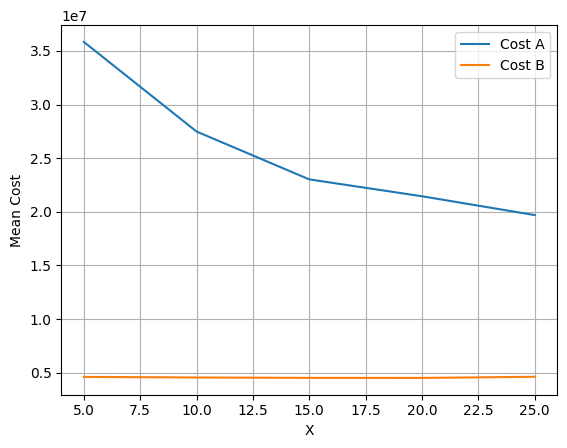

In [25]:
mean_costs_A = [np.mean([i[0] for i in cc]) for cc in costs]
mean_costs_B = [np.mean([i[1] for i in cc]) for cc in costs]
plt.plot([5, 10, 15, 20, 25], mean_costs_A, label='Cost A')
plt.plot([5, 10, 15, 20, 25], mean_costs_B, label='Cost B')
plt.xlabel('X')
plt.ylabel('Mean Cost')
plt.legend()
plt.grid()
plt.show()

### Question 3(b): Linear Regression

The objective is to compute and compare the linear regression loss (sum of squared errors) on the original data $(D, y)$ using two different solution vectors:
1.  **Solution b:** The optimal solution computed from the original data $(D, y)$.
2.  **Solution a:** The optimal solution computed from the projected data $(E, z)$, where $E = MD$ and $z = My$.

**Formulas:**

* **Projection Matrix:** $M \in \mathbb{R}^{x \times n}$
* **Projected Data:** $E = MD$
* **Projected Target:** $z = My$
* **Solution from Projected Data:** $a$
* **Solution from Original Data:** $b$
* **Loss using Solution a:**
    $$Loss(D,y,a)=||Da-y||_{2}^{2}$$
* **Loss using Solution b:**
    $$Loss(D,y,b)=||Db-y||_{2}^{2}$$

In [17]:
Y = dataset.target
YLABEL = Normalise(pd.DataFrame(Y)).to_numpy()
# print((pd.DataFrame(YLABEL))[0].unique())

C:\Users\jonsn\AppData\Local\Temp\ipykernel_16404\2273557515.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normal[i] = normal[i].replace(uni[j], j)


In [18]:
loss = []

for X in [25, 50, 100, 200, 500]:
    loss.extend([[]])
    for j in tqdm(range(5)):
        probabs = np.random.rand(X, N)
        M = np.zeros((X, N))
        M[probabs < 1/6] = np.sqrt(3/X)
        M[probabs > 5/6] = -np.sqrt(3/X)
        MSPA = csc_matrix(M)
        
        E = MSPA @ DATA
        Z = MSPA @ YLABEL
        
        # print('le')
        lE = LinearRegression(fit_intercept=False)
        lE.fit(E, Z)
        A = lE.coef_
    
        lDATA = LinearRegression(fit_intercept=False)
        lDATA.fit(DATA, YLABEL)
        B = lDATA.coef_
        # print('done')
        # print(A.shape)
        # print(B.shape)
        # print(MSPA.shape)
        LossA = Losses(DATA, YLABEL, A)
        LossB = Losses(DATA, YLABEL, B)
        loss[-1].append((LossA, LossB))
    
for i in range(len(loss)):
    print(f'X = {(i+1)*5}')
    for j in range(5):
        print(f'Loss(A) : {loss[i][j][0]}, Loss(B) : {loss[i][j][1]}')
    print()

100%|██████████| 5/5 [01:27<00:00, 17.47s/it]

X = 5
Loss(A) : 892822809.6476912, Loss(B) : 104939938.96614683
Loss(A) : 752959710.7240098, Loss(B) : 104939938.96614683
Loss(A) : 793597132.5135674, Loss(B) : 104939938.96614683
Loss(A) : 1504991434.8370306, Loss(B) : 104939938.96614683
Loss(A) : 489928872.4608011, Loss(B) : 104939938.96614683

X = 10
Loss(A) : 253142332.23768306, Loss(B) : 104939938.96614683
Loss(A) : 586409692.6637707, Loss(B) : 104939938.96614683
Loss(A) : 327964085.42536175, Loss(B) : 104939938.96614683
Loss(A) : 291704934.7915703, Loss(B) : 104939938.96614683
Loss(A) : 427363535.0368524, Loss(B) : 104939938.96614683

X = 15
Loss(A) : 143624994.43149394, Loss(B) : 104939938.96614683
Loss(A) : 194553003.8074234, Loss(B) : 104939938.96614683
Loss(A) : 179566196.16774994, Loss(B) : 104939938.96614683
Loss(A) : 172100396.65841392, Loss(B) : 104939938.96614683
Loss(A) : 180126729.56974965, Loss(B) : 104939938.96614683

X = 20
Loss(A) : 130472253.60430577, Loss(B) : 104939938.96614683
Loss(A) : 122577008.94597653, Loss

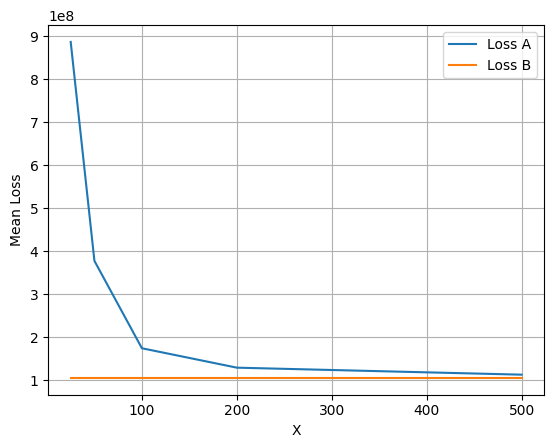

In [19]:
m_loss_A = [np.mean([i[0] for i in ll]) for ll in loss]
m_loss_B = [np.mean([i[1] for i in ll]) for ll in loss]
plt.plot([25, 50, 100, 200, 500], m_loss_A, label='Loss A')
plt.plot([25, 50, 100, 200, 500], m_loss_B, label='Loss B')
plt.xlabel('X')
plt.ylabel('Mean Loss')
plt.legend()
plt.grid()
plt.show()